# Instructie

Voor het oplossen van complexe constructies met differentiaalvergelijkingen loopt het aantal vergelijkingen snel op. In deze les gaan we daarom aan de slag met SymPy, een Python-bibliotheek waarmee we symbolisch kunnen rekenen. Hiermee hoeven we de berekeningen niet met de hand te doen.

We gebruiken SymPy om de vergelijkingen op te stellen, te integreren, een stelsel vergelijkingen op te stellen, de integratieconstantes te bepalen en uiteindelijk een plotje te maken van de oplossing. Met name voor het oplossen van het stelsel vergelijkingen is SymPy erg handig.

## SymPy installeren en laden

Om SymPy te gebruiken moet je deze installeren. In het tweede jaar leer je hoe je python installeert en uitbreidt met bibliotheken zoals SymPy. Voor nu kun je SymPy gebruiken in dit online boek of in WebLab, waar het al voor je is geïnstalleerd. Om in dit boek python te activeren klik je op {fa}`rocket` --> {guilabel}`Live Code`. Het enige wat je dan nog moet doen in een python script is het inladen van de bibliotheek:

```python
import sympy as sym
```

In [2]:
import sympy as sym
sym.init_printing(use_latex='mathjax')
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display as ipy_display, Math

%config InlineBackend.figure_formats = ['svg']

def display(*objs):
    for obj in objs:
        if isinstance(obj, dict):
            lines = [f"{sym.latex(k)} &= {sym.latex(obj[k])}" for k in sorted(obj, key=lambda s: str(s))]
            ipy_display(Math(r"\begin{aligned}" + r"\\ ".join(lines) + r"\end{aligned}"))
        else:
            ipy_display(obj)

def plot(w_list, x_range_list,ylabel):
    fig = plt.figure(facecolor='none')
    for i, w in enumerate(w_list):
        # check if x is the only symbol in the expression
        if len(w.free_symbols) > 1:
            raise ValueError('The expression must be a function of x only.')
        
        w_numpy = sym.lambdify(x, w)
        x_vals = np.linspace(x_range_list[i][0], x_range_list[i][1], 100)
        
        # if the expression is a constant, we need to make sure that it is broadcasted correctly
        if isinstance(w_numpy(x_vals),float) or isinstance(w_numpy(x_vals),int):
            w_numpy = np.vectorize(w_numpy)
        plt.plot(x_vals,w_numpy(x_vals))

        plt.xlabel('$x$')
        plt.ylabel(ylabel)
    ax = plt.gca()
    ax.set_facecolor('none')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.invert_yaxis()

Vervolgens kun je de functies van SymPy gebruiken door `sym.` voor de functienaam te zetten.

## SymPy syntax

Om SymPy te gebruiken, moet je de juiste syntax kennen. Hier zijn enkele basisprincipes:

- Symbolen definiëren: Je kunt symbolen (alle wiskundige symbolen waarvan je de waarde nog niet weet) definiëren met de `var` functie met daarin een lijstje symbolen. Bijvoorbeeld:
    ```python
    sym.var('x, F, C1')
    ```
- Je kan berekeningen maken en die opslaan in variabelen. Gebruik daarvoor de reguliere symbolen, maar `**` voor machtsverheffen. Bijvoorbeeld:
    ```python
    M = F**2 + 3*5
    q = 5 * x
    ```
- Je kan functies integreren met de `integrate` functie waarbij je eerst de variabele ingeeft die je wilt integreren en vervolgens de variabele waarnaar je wilt integreren (meestal `x`). Let erop dat je daarnaast nog zelf de onbekende integratieconstantes moet toevoegen. Bijvoorbeeld:
    ```python
    V = -sym.integrate(q, x) + C1
    ```
- Je kan vergelijkingen opstellen met de `Eq` functie. Definieer de linker en rechterzijde met een `,` ertussen. Gebruik daarbij de `.subs` functie om onbekende symbolen (vaak waardes van `x`) te vervangen met een waarde. Voor `subs` geef je zowel de onbekende als waarde aan waarmee je die onbekende wilt vervangen. Bijvoorbeeld:
    ```python
    eq = sym.Eq(V.subs(x,10), 0)
    ```
- Je kan een vergelijkingen (een enkele of een stelsel) oplossen met de `solve` functie. Geef de vergelijking of het stelsel als eerste argument en de onbekende symbolen als tweede argument (in een lijstje). Bijvoorbeeld:
    ```python
    sol = sym.solve([eq,eq2], [C1,C3])
    ```
- Je kan deze oplossing substitueren in je oorspronkelijke variabelen met dezelfde `subs` functie. Bijvoorbeeld:
    ```python
    V_oplossing = V.subs(sol)
    ```
- Je kan de resultaten tonen met de `display` functie. Deze is geen onderdeel van SymPy, dus heeft geen `sym.`nodig. Bijvoorbeeld:
    ```python
    display(V_oplossing)
    ```
- Een resultaat op een bepaalde waarde kunnen we vinden door de `subs` en `display` functies te combineren. Bijvoorbeeld:
    ```python
    display(V_oplossing.subs(x, 5))
    ```
- Je kan je resultaten plotten met de `plot` functie. Dit is een speciale functie die is klaargezet in dit online boek en in WebLab. Als input geef je een lijstje van vergelijkingen met elk enkel `x` als onbekend symbool. Daarnaast geef je een lijst met begin en eindpunten voor elk domein van `x` waarvoor je elke vergelijking wilt plotten. Tot slot geeft je de naam van de verticale as in. Bijvoorbeeld:
    ```python
    plot([V_oplossing, V_oplossing_2], [[0, 10],[10,20]], 'V')
    ```
- Mocht je het nulpunt van een bepaalde functie willen vinden, dan kun je de `solve` functie gebruiken. Geef als eerste argument de vergelijking waarvan je het nulpunt wilt vinden en als tweede argument de onbekende. Hier komt een lijst uit met één of meerdere oplossingen. Gebruik `[0]` achter de functie om het eerste nulpunt te krijgen, `[1]` voor het tweede nulpunt, enz. Bijvoorbeeld:
    ```python
    nulpunt = sym.solve(sym.Eq(V_oplossing, 0), x)[0]
    display(nulpunt)
    ```
- Als alle waardes als gehele getallen of breuken zijn ingevoerd, kan SymPy ook een exacte oplossing geven. Je kunt deze oplossing ook omzetten naar een decimale benadering met `evalf()`. Bijvoorbeeld:
    ```python
    display(nulpunt.evalf())
    ```
- Tot slot kan je opmerkingen in je code toevoegen met `#`. Alles wat na `#` staat, wordt genegeerd door Python. Bijvoorbeeld:
    ```python
    # Dit is een opmerking
    ```

## Standaardprocedure

De aanpak voor het oplossen van constructies met differentiaalvergelijkingen is altijd gelijk, omdat de differentiaalvergelijkingen voor buiging altijd hetzelfde zijn:

$$
\begin{align*}
\cfrac{dV\left(x\right)}{dx} &= -q_z \left(x\right) \\
\cfrac{dM\left(x\right)}{dx} &= V\left(x\right) \\
M\left(x\right) &= EI\left(x\right) \cdot \kappa\left(x\right) \\
\cfrac{d\varphi\left(x\right)}{dx} &= \kappa\left(x\right) \\
\cfrac{dw\left(x\right)}{dx} &= - \varphi\left(x\right)
\end{align*}
$$

Of voor extensie:

$$
\begin{align*}
\cfrac{dN\left(x\right)}{dx} &= -q_x \left(x\right) \\
N\left(x\right) &= EA\left(x\right) \cdot \varepsilon\left(x\right) \\
\cfrac{dw\left(x\right)}{dx} &= \varepsilon\left(x\right)
\end{align*}
$$

Dus we zullen altijd de volgende procedure volgen:

::::::{prf:algorithm-start} Doorrekenen constructie met SymPy
:label: alg_sympy
:nonumber: true

::::::

In [15]:
import sympy as sym

In [42]:
sym.var('x')
sym.var('C1 C2 C3 C4 ...');

In [ ]:
q1 = ...
...

In [ ]:
V1 = sym.integrate(-q1,x)+C1
M1 = sym.integrate(V1,x)+C2
kappa1 = M1 / ...
phi1 = sym.integrate(kappa1,x)+C3
w1 = sym.integrate(-phi1,x)+C4

...

In [ ]:
Eq1 = sym.Eq(...,...)
Eq2 = ...

In [ ]:
sol = sym.solve((Eq1, Eq2, Eq3, Eq4, ...), (C1, C2, C3, C4, ...))
display(sol)

In [ ]:
..._oplossing = ....subs(sol)
...

display(..._oplossing)

De volgende code is al ingeladen. Deze code is gegeven mocht je de plotjes willen maken in een python omgeving waarin deze niet is klaargezet.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot(w_list, x_range_list,ylabel):
    fig = plt.figure(facecolor='none')
    for i, w in enumerate(w_list):
        # check if x is the only symbol in the expression
        if len(w.free_symbols) > 1:
            raise ValueError('The expression must be a function of x only.')
        
        w_numpy = sym.lambdify(x, w)
        x_vals = np.linspace(x_range_list[i][0], x_range_list[i][1], 100)
        
        # if the expression is a constant, we need to make sure that it is broadcasted correctly
        if isinstance(w_numpy(x_vals),float) or isinstance(w_numpy(x_vals),int):
            w_numpy = np.vectorize(w_numpy)
        plt.plot(x_vals,w_numpy(x_vals))
        plt.xlabel('$x$')
        plt.ylabel(ylabel)
    ax = plt.gca()
    ax.set_facecolor('none')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.invert_yaxis()

In [ ]:
plot([...,...],[...,...],'...')

::::::{prf:algorithm-end}
::::::

````{margin}
```{attributiongrey} Bronvermelding
:class: attribution

Deze oefening is gebaseerd op [een voorbeeld uit het online boek Structural Mechanics @ BSc Civil Engineering van de Technische Universiteit Delft](https://oit.tudelft.nl/CEG-mechanics-BSc/tools/sympy_mech.html) {cite:p}`CEG_mechanics_BSc`.

```
````

## Voorbeeld

Het doorreken van de constructie met SymPy wordt getoond in het volgende voorbeeld

::::::{prf:example-start}
:nonumber: true
::::::

```{figure-start} ./instructie_data/constructie.svg
:class: sticky-margin
:align: center
:source: https://github.com/Structural-Mechanics-CEG/mechanics-figures-source/tree/main/sympy
:number:
```

$$EI = 50 \, \rm{MNm}^2$$

```{figure-end}
```

Waarvoor de momenten en doorbuigingslijn is gevraagd en de waardes in $x = 5$.

We volgen de standaardprocedure zoals hierboven beschreven.

In [3]:
import sympy as sym

De constructie moet worden beschreven met drie losse domeinen: $0 \lt x \lt 4$, $4 \lt x \lt 9$ en $9 \lt x \lt 15$. Op elk domein is de vierde-orde differentiaalvergelijking geldig, dus we moeten uiteindelijk 12 integratieconstantes bepalen.

In [4]:
sym.var('x')
sym.var('C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11, C12');

Voor elk domein moet de belastingsfunctie $q \left(x\right)$ worden gedefinieerd. Op het eerste domein is er een verdeelde belasting in de positieve $z$-richting, terwijl er op de andere domeinen geen belasting is. Dit geeft:

In [5]:
q1 = 10
q2 =  0
q3 =  0

Nu kunnen we SymPy deze belastingsfuncties laten integereren. Daarbij hebben de waarde van $EI$ nodig.

In [6]:
V1 = sym.integrate(-q1,x)+C1
M1 = sym.integrate(V1,x)+C2
kappa1 = M1 / 50000
phi1 = sym.integrate(kappa1,x)+C3
w1 = sym.integrate(-phi1,x)+C4

V2 = sym.integrate(-q2,x)+C5
M2 = sym.integrate(V2,x)+C6
kappa2 = M2 / 50000
phi2 = sym.integrate(kappa2,x)+C7
w2 = sym.integrate(-phi2,x)+C8

V3 = sym.integrate(-q3,x)+C9
M3 = sym.integrate(V3,x)+C10
kappa3 = M3 / 50000
phi3 = sym.integrate(kappa3,x)+C11
w3 = sym.integrate(-phi3,x)+C12

Nu kunnen we de rand- en overgangsvoorwaarden opstellen. Voor de randvoorwaarden geldt dat de verplaatsingen en momenten op $x=0$ en $x=15$ nul moeten zijn:

In [7]:
Eq1 = sym.Eq(w1.subs(x, 0), 0)
Eq2 = sym.Eq(M1.subs(x, 0), 0)
Eq3 = sym.Eq(w3.subs(x, 15), 0)
Eq4 = sym.Eq(M3.subs(x, 15), 0)

In de overgangen op $x=4$ en $x=9$ geldt dat de verplaatsingen en hellingen aan elkaar gelijk moeten zijn:

In [8]:
Eq5 = sym.Eq(w1.subs(x, 4), w2.subs(x, 4))
Eq6 = sym.Eq(phi1.subs(x, 4), phi2.subs(x, 4))
Eq7 = sym.Eq(w2.subs(x, 9), w3.subs(x, 9))
Eq8 = sym.Eq(phi2.subs(x, 9), phi3.subs(x, 9))

In overgang $\rm{C}$ op $x=4$ geldt dat de momenten en dwarskrachten aan elkaar gelijk moeten zijn omdat er geen uitwendige belasting is op dat punt. In overgang $\rm{D}$ op $x=9$ is er wel een uitwendige puntlast, dus daar geldt dat de momenten aan elkaar gelijk moeten zijn, maar dat de dwarskrachten een verschil van 10 kN moeten hebben:

```{figure} ./instructie_data/FBD.svg
:align: center
:source: https://github.com/Structural-Mechanics-CEG/mechanics-figures-source/tree/main/sympy
:number:
```

$$
\begin{align*}
\sum F_{\rm{v}} & = 0 \\
-V_2 \left(9\right) + 35 + V_3 \left(9\right) & = 0
\end{align*}
$$

In [9]:
Eq9 = sym.Eq(V1.subs(x, 4), V2.subs(x, 4))
Eq10 = sym.Eq(M1.subs(x, 4), M2.subs(x, 4))
Eq11 = sym.Eq(M2.subs(x, 9), M3.subs(x, 9))
Eq12 = sym.Eq(-V2.subs(x, 9) + 35 + V3.subs(x, 9), 0)

Nu kunnen alle integratieconstanten worden opgelost:

In [10]:
sol = sym.solve((Eq1, Eq2, Eq3, Eq4, Eq5, Eq6, Eq7, Eq8, Eq9, Eq10, Eq11, Eq12), (C1, C2, C3, C4, C5, C6, C7, C8, C9, C10, C11, C12))
display(sol)

<IPython.core.display.Math object>

De verplaatsingsfunctie en momentenlijn kan nu worden gevonden:

In [11]:
w1_oplossing = w1.subs(sol)
display(w1_oplossing)
w2_oplossing = w2.subs(sol)
display(w2_oplossing)
w3_oplossing = w3.subs(sol)
display(w3_oplossing)
M1_oplossing = M1.subs(sol)
display(M1_oplossing)
M2_oplossing = M2.subs(sol)
display(M2_oplossing)
M3_oplossing = M3.subs(sol)
display(M3_oplossing)

   4         3          
  x      73⋅x     6673⋅x
────── - ────── + ──────
120000   450000   450000

      3      2                 
  13⋅x      x     7633⋅x    4  
- ────── - ──── + ────── - ────
  450000   1250   450000   1875

    3        2                  
79⋅x     79⋅x    40781⋅x   5231 
────── - ───── + ─────── - ─────
900000   20000   900000    60000

     2   146⋅x
- 5⋅x  + ─────
           3  

26⋅x     
──── + 80
 3       

      79⋅x
395 - ────
       3  

De waardes in $\rm{B}$ kunnen worden gevonden:

In [12]:
display(w1_oplossing.subs(x, 5))
display(w1_oplossing.subs(x, 5).evalf())
display(M1_oplossing.subs(x, 5))
display(M1_oplossing.subs(x, 5).evalf())

2363 
─────
40000

0.0590750000000000

355/3

118.333333333333

Deze oplossingen kunnen worden geplot:

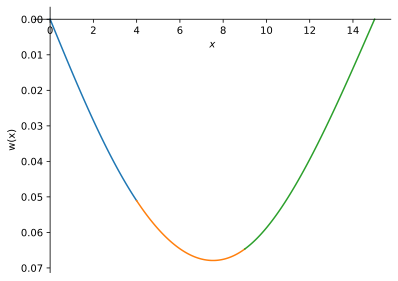

In [13]:
plot([w1_oplossing, w2_oplossing, w3_oplossing], [(0, 4), (4, 9), (9, 15)], 'w(x)')

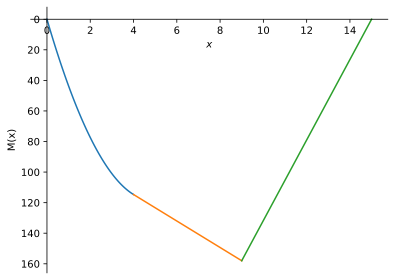

In [14]:
plot([M1_oplossing, M2_oplossing, M3_oplossing], [(0, 4), (4, 9), (9, 15)], 'M(x)')

Dit voorbeeld is ook beschikbaar in [WebLab](https://weblab.tudelft.nl/ctb1310/2025-2026/assignment/163456). Heb je nog geen toegang? Schrijf je dan eerst [hier](https://weblab.tudelft.nl/ctb1310/2025-2026/enroll) in voor dit vak op WebLab.

::::::{prf:example-end}
::::::

```{hide-sticky-margin}
```

## Instructies in collegevorm
Dit onderwerp is [in les 18](https://collegerama.tudelft.nl/Mediasite/Channel/public-ctb1310/watch/242ffad01ebd47d0a6991185db1323911d) gepresenteerd in collegevorm van 12:40 tot 57:30.


## Oefeningen
[Opgaves 8.7 - 8.11, 8.26 - 8.31, 8.34 - 8.37 in hoofdstuk 8 van het boek Mechanica, spanningen, vervormingen en verplaatsingen](https://icozct.tudelft.nl/TUD_CT/boekantwoorden/files/TM2vraagstukkenbundel.pdf) {cite:p}`Hartsuijker2013`. Los de opgaves op met SymPy. Antwoorden zijn [hier](https://icozct.tudelft.nl/TUD_CT/boekantwoorden/vol2/Chapter8/) beschikbaar.